## 🧪 **Praktikum Genetic Algorithm (GA) – Python**

memahami konsep GA (populasi, seleksi, crossover, mutasi) dan mengamati evolusi solusi terbaik per generasi.


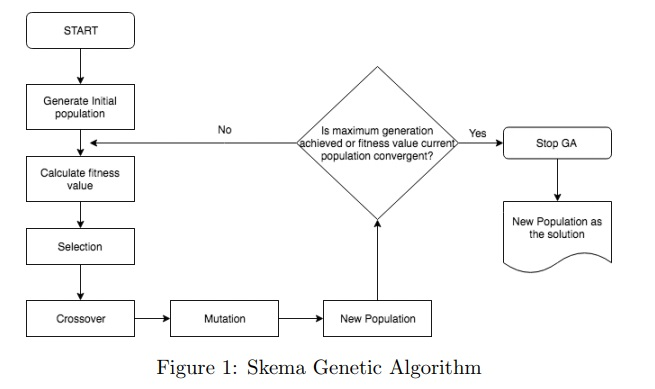

## Import Library

Kita menggunakan modul `random` untuk membuat populasi awal, seleksi, crossover, dan mutasi.


In [ ]:
import random


## Parameter Praktikum

Parameter mengatur perilaku evolusi. Silakan ubah untuk eksperimen:
- `POP_SIZE`: ukuran populasi
- `CHROMOSOME_LENGTH`: panjang kromosom biner (5 bit → nilai 0..31)
- `GENERATIONS`: jumlah generasi
- `MUTATION_RATE`: peluang mutasi per gen
- `USE_SEED`: agar hasil mudah direproduksi


In [ ]:
POP_SIZE = 6              # jumlah individu
CHROMOSOME_LENGTH = 5     # 5 bit -> nilai 0..31
GENERATIONS = 50          # jumlah generasi
MUTATION_RATE = 0.01      # peluang mutasi per gen
USE_SEED = True
SEED_VALUE = 42

if USE_SEED:
    random.seed(SEED_VALUE)


## Representasi Kromosom

Kromosom direpresentasikan sebagai **string biner** sepanjang 5 bit.
Contoh: `'10101'` → 21 (desimal). Kita sediakan fungsi bantu `decode` dan `encode`.


In [ ]:
def decode(chromosome: str) -> int:
    """Biner -> Desimal."""
    return int(chromosome, 2)

def encode(x: int, length: int = CHROMOSOME_LENGTH) -> str:
    """Desimal -> Biner dengan panjang tetap."""
    return format(x, f'0{length}b')


## Fungsi Fitness

Fitness mengukur kualitas solusi. Di sini digunakan **f(x) = x²**.
Semakin besar nilai kuadrat, semakin baik kualitas solusi.


In [ ]:
def fitness(chromosome: str) -> int:
    x = decode(chromosome)
    return x * x  # f(x) = x^2


## Inisialisasi Populasi

Membuat populasi awal secara acak sebanyak `POP_SIZE` individu, masing-masing berupa string biner.


In [ ]:
def init_population(size: int, chromosome_length: int):
    population = []
    for _ in range(size):
        chrom = ''.join(random.choice('01') for _ in range(chromosome_length))
        population.append(chrom)
    return population


## Seleksi (Roulette Wheel)

Memilih induk secara **proporsional** terhadap nilai fitness: individu yang lebih fit punya peluang lebih besar terpilih.
Jika semua fitness = 0, fallback ke pemilihan acak.


In [ ]:
def selection(population):
    total_fit = sum(fitness(ch) for ch in population)
    if total_fit <= 0:
        return random.choice(population)
    pick = random.uniform(0, total_fit)
    running = 0
    for ch in population:
        running += fitness(ch)
        if running >= pick:
            return ch
    return population[-1]  # fallback


## Crossover (Satu Titik)

Menggabungkan dua induk di satu titik potong untuk menghasilkan dua anak.
Tujuan: eksplorasi kombinasi gen yang menjanjikan.


In [ ]:
def crossover(parent1: str, parent2: str):
    if len(parent1) != len(parent2):
        raise ValueError("Panjang kromosom induk harus sama.")
    # titik potong di antara [1 .. length-1]
    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2
123456  654321
chil1 :

## Mutasi

Membalik bit secara acak dengan peluang kecil (`MUTATION_RATE`).
Fungsi: menjaga **keragaman** populasi dan mencegah stagnasi.


In [ ]:
def mutate(chromosome: str, mutation_rate: float = MUTATION_RATE) -> str:
    bits = list(chromosome)
    for i in range(len(bits)):
        if random.random() < mutation_rate:
            bits[i] = '1' if bits[i] == '0' else '0'
    return ''.join(bits)


## Algoritma Utama GA

Langkah-langkah:
1) Inisialisasi populasi
2) Untuk tiap generasi: seleksi pasangan, crossover, mutasi → bentuk populasi baru
3) Evaluasi dan simpan solusi terbaik (elitisme sederhana via tracking terbaik)
4) Berhenti jika jumlah generasi tercapai/nilai stagnan


In [ ]:
def genetic_algorithm(pop_size=POP_SIZE, chromosome_length=CHROMOSOME_LENGTH,
                      generations=GENERATIONS, patience=50):
    population = init_population(pop_size, chromosome_length)
    best_solution = None
    best_fitness = float('-inf')
    stagnant_count = 0  # hitung generasi tanpa peningkatan

    for gen in range(1, generations + 1):
        new_population = []

        # hasilkan populasi baru
        for _ in range(pop_size // 2):
            p1 = selection(population)
            p2 = selection(population)
            c1, c2 = crossover(p1, p2)
            c1 = mutate(c1)
            c2 = mutate(c2)
            new_population.extend([c1, c2])

        if len(new_population) < pop_size:
            new_population.append(''.join(random.choice('01') for _ in range(chromosome_length)))

        population = new_population[:pop_size]

        # tracking solusi terbaik
        gen_best = float('-inf')
        gen_best_sol = None
        for ch in population:
            fit = fitness(ch)
            if fit > gen_best:
                gen_best = fit
                gen_best_sol = ch

        # cek apakah ada peningkatan global
        if gen_best > best_fitness:
            best_fitness = gen_best
            best_solution = gen_best_sol
            stagnant_count = 0  # reset kalau ada peningkatan
        else:
            stagnant_count += 1

        print(f"Generasi {gen:02d} | Best = {best_solution} "
              f"(x={decode(best_solution)}) | fitness = {best_fitness}")

        # stop kalau stagnan terlalu lama
        if stagnant_count >= patience:
            print(f"\n=== Hentikan dini di generasi {gen} karena fitness stagnan {patience}x ===")
            break

    print("\n=== Hasil Akhir ===")
    print(f"Solusi terbaik: {best_solution} (x={decode(best_solution)}) dengan fitness = {best_fitness}")
    return best_solution, best_fitness


## Jalankan GA

Jalankan algoritma dan amati output per generasi. Idealnya solusi terbaik mendekati `x = 31` (fitness = 961).


In [ ]:
_ = genetic_algorithm()


Generasi 01 | Best = 11011 (x=27) | fitness = 729
Generasi 02 | Best = 11011 (x=27) | fitness = 729
Generasi 03 | Best = 11011 (x=27) | fitness = 729
Generasi 04 | Best = 11011 (x=27) | fitness = 729
Generasi 05 | Best = 11011 (x=27) | fitness = 729
Generasi 06 | Best = 11011 (x=27) | fitness = 729
Generasi 07 | Best = 11011 (x=27) | fitness = 729
Generasi 08 | Best = 11011 (x=27) | fitness = 729
Generasi 09 | Best = 11111 (x=31) | fitness = 961
Generasi 10 | Best = 11111 (x=31) | fitness = 961
Generasi 11 | Best = 11111 (x=31) | fitness = 961
Generasi 12 | Best = 11111 (x=31) | fitness = 961
Generasi 13 | Best = 11111 (x=31) | fitness = 961
Generasi 14 | Best = 11111 (x=31) | fitness = 961
Generasi 15 | Best = 11111 (x=31) | fitness = 961
Generasi 16 | Best = 11111 (x=31) | fitness = 961
Generasi 17 | Best = 11111 (x=31) | fitness = 961
Generasi 18 | Best = 11111 (x=31) | fitness = 961
Generasi 19 | Best = 11111 (x=31) | fitness = 961
Generasi 20 | Best = 11111 (x=31) | fitness = 961


## (Opsional) Visualisasi Perkembangan Fitness

Jika ingin memplot kenaikan fitness terbaik per generasi, simpan riwayat dan plot (butuh `matplotlib`).


Generasi 01 | GlobalBest = 841
Generasi 02 | GlobalBest = 841
Generasi 03 | GlobalBest = 841
Generasi 04 | GlobalBest = 841
Generasi 05 | GlobalBest = 841
Generasi 06 | GlobalBest = 841
Generasi 07 | GlobalBest = 841
Generasi 08 | GlobalBest = 841
Generasi 09 | GlobalBest = 841
Generasi 10 | GlobalBest = 841
Generasi 11 | GlobalBest = 841
Generasi 12 | GlobalBest = 841
Generasi 13 | GlobalBest = 841
Generasi 14 | GlobalBest = 841
Generasi 15 | GlobalBest = 841
Generasi 16 | GlobalBest = 841
Generasi 17 | GlobalBest = 841
Generasi 18 | GlobalBest = 841
Generasi 19 | GlobalBest = 841
Generasi 20 | GlobalBest = 841
Generasi 21 | GlobalBest = 841
Generasi 22 | GlobalBest = 841
Generasi 23 | GlobalBest = 841
Generasi 24 | GlobalBest = 841
Generasi 25 | GlobalBest = 841
Generasi 26 | GlobalBest = 841
Generasi 27 | GlobalBest = 841
Generasi 28 | GlobalBest = 841
Generasi 29 | GlobalBest = 841
Generasi 30 | GlobalBest = 841
Generasi 31 | GlobalBest = 841
Generasi 32 | GlobalBest = 961
Generasi

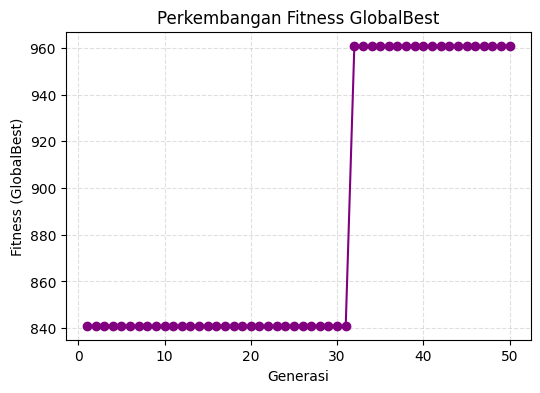

In [ ]:
def genetic_algorithm_with_global(pop_size=POP_SIZE,
                                  chromosome_length=CHROMOSOME_LENGTH,
                                  generations=GENERATIONS):
    population = init_population(pop_size, chromosome_length)
    best_solution = None
    best_fitness = float('-inf')
    hist_globalbest = []

    for gen in range(1, generations + 1):
        new_population = []
        for _ in range(pop_size // 2):
            p1 = selection(population)
            p2 = selection(population)
            c1, c2 = crossover(p1, p2)
            c1 = mutate(c1)
            c2 = mutate(c2)
            new_population.extend([c1, c2])

        if len(new_population) < pop_size:
            new_population.append(''.join(random.choice('01') for _ in range(chromosome_length)))

        population = new_population[:pop_size]

        # evaluasi generasi ini
        for ch in population:
            fit = fitness(ch)
            if fit > best_fitness:
                best_fitness = fit
                best_solution = ch

        hist_globalbest.append(best_fitness)
        print(f"Generasi {gen:02d} | GlobalBest = {best_fitness}")

    return best_solution, best_fitness, hist_globalbest

# Contoh jalankan dan plot
best_sol, best_fit, hist_global = genetic_algorithm_with_global()

plt.figure(figsize=(6,4))
plt.plot(range(1, len(hist_global)+1), hist_global, marker='o', color='purple')
plt.xlabel("Generasi")
plt.ylabel("Fitness (GlobalBest)")
plt.title("Perkembangan Fitness GlobalBest")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Hasil & Analisis Singkat

- Perhatikan bagaimana **fitness terbaik** meningkat atau stabil seiring generasi.
- Solusi optimal untuk fungsi ini adalah **x = 31** dengan **fitness = 961**.
- Parameter memengaruhi kecepatan konvergensi:
  - Populasi besar → eksplorasi lebih baik, tetapi lebih lambat.
  - Mutasi terlalu kecil → risiko stagnasi; terlalu besar → solusi tidak stabil.
  - Generasi terlalu sedikit → belum sempat konvergen.


## **Demo**
[Click disini](https://ga-kb.vercel.app/)

In [ ]:
import random

print("=== Tanpa seed ===")
# Tidak set seed → Python otomatis pakai waktu sistem sebagai acuan
print("Run 1:", [random.random() for _ in range(5)])
print("Run 2:", [random.random() for _ in range(5)])

print("\n=== Dengan seed ===")
#makek seed 42
random.seed(42)
print("Run 1 (seed=42):", [random.random() for _ in range(5)])


random.seed(42)
print("Run 2 (seed=42):", [random.random() for _ in range(5)])


random.seed(10)
print("Run 3 (seed=10):", [random.random() for _ in range(5)])

random.seed(10)
print("Run 3 (seed=10):", [random.random() for _ in range(5)])


=== Tanpa seed ===
Run 1: [0.8235888725334455, 0.6534725339011758, 0.16022955651881965, 0.5206693596399246, 0.32777281162209315]
Run 2: [0.24999667668640035, 0.9528169091459117, 0.9965569925394552, 0.04455638245043303, 0.860161037286291]

=== Dengan seed ===
Run 1 (seed=42): [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Run 2 (seed=42): [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Run 3 (seed=10): [0.5714025946899135, 0.4288890546751146, 0.5780913011344704, 0.20609823213950174, 0.81332125135732]
Run 3 (seed=10): [0.5714025946899135, 0.4288890546751146, 0.5780913011344704, 0.20609823213950174, 0.81332125135732]


Xₙ₊₁ = (a * Xₙ + c) mod m

## Tugas Mandiri

1) Ganti fungsi fitness (misal: `f(x) = sin(x) + x^2`) dan amati perbedaannya.
2) Coba variasikan parameter (`POP_SIZE`, `GENERATIONS`, `MUTATION_RATE`) dan catat pengaruhnya.
3) Modifikasi seleksi (mis. turnamen) atau tambahkan elitisme (bawa 1-2 individu terbaik ke generasi berikutnya).
